# Grid Search + GroupKFold por Muestra Física
**Resuelve observación #1 del revisor: data leakage por pseudoreplicación**

Cada fold garantiza que TODAS las imágenes de una muestra física están
siempre en el mismo conjunto (train o validación), nunca en ambos.

---
### Estructura del experimento
- **Dataset train**: 5,595 imágenes de 25 muestras físicas
- **Hold-out**: 920 imágenes de 4 muestras (separadas en carpeta `val`, NO se usan aquí)
- **Validación interna**: GroupKFold con 5 folds, agrupando por muestra física
- **Modelos**: EfficientNet-B0 | AlexNet | MobileNetV2 | SqueezeNet 1.0

Corre **una celda de modelo a la vez** y revisa los resultados antes de continuar.

---
## CELDA 0 — Imports, configuración y funciones base
**Corre esta celda siempre primero.**

In [17]:
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# *** CAMBIA ESTA RUTA A TU CARPETA TRAIN ***
# ============================================================
TRAIN_DIR = r"C:/Users/Itz/Documents/DOCTORADO/ART-SS-TL-EV/datasetGF/train"

CONFIG = {
    "train_dir"    : TRAIN_DIR,
    "learning_rates": [5e-3, 5e-4, 5e-5, 5e-6],
    "epochs"       : 30,
    "batch_size"   : 50,
    "n_splits"     : 3,
    "num_classes"  : 3,
    "image_size"   : 224,
    "random_seed"  : 42
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.4.1+cu124


In [18]:
# ============================================================
# Extractor de ID de muestra desde el nombre de archivo
# Acepta: S{N}-4_frame_XXXX.jpg  y  S{N}_frame_XXXX.jpg (S24)
# ============================================================
def extract_sample_id(filename: str) -> str:
    name = Path(filename).stem
    match = re.match(r'^(S\d+)-\d+_frame_\d+$', name)
    if match:
        return match.group(1)
    match = re.match(r'^(S\d+)_frame_\d+$', name)
    if match:
        return match.group(1)
    raise ValueError(f"No se pudo extraer el ID de muestra de: {filename}")


# ============================================================
# Dataset
# ============================================================
class TSSDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir   = Path(image_dir)
        self.transform   = transform
        self.images      = []
        self.labels      = []
        self.groups      = []
        self.class_names = ['3Baja', '2Media', '1Alta']

        for class_idx, class_name in enumerate(self.class_names):
            class_path = self.image_dir / class_name
            for img_path in sorted(class_path.glob('*.*')):
                self.images.append(str(img_path))
                self.labels.append(class_idx)
                self.groups.append(extract_sample_id(img_path.name))

        self.groups_array = np.array(self.groups)
        unique_groups = sorted(set(self.groups), key=lambda x: int(x[1:]))

        print(f"Imágenes cargadas   : {len(self.images)}")
        print(f"Distribución clases : {np.bincount(self.labels)} "
              f"(3Baja | 2Media | 1Alta)")
        print(f"Muestras físicas    : {len(unique_groups)} → {unique_groups}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]


# ============================================================
# Transformaciones
# ============================================================
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


# ============================================================
# Función de entrenamiento de un fold
# ============================================================
def train_one_fold(model, train_loader, val_loader, lr, model_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    for epoch in range(CONFIG["epochs"]):
        model.train()
        for images, labels in tqdm(train_loader, leave=False,
                                   desc=f"Epoch {epoch+1}/{CONFIG['epochs']}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            if model_name == 'squeezenet':
                outputs = outputs.squeeze(-1).squeeze(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if model_name == 'squeezenet':
                outputs = outputs.squeeze(-1).squeeze(-1)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            gts.extend(labels.cpu().numpy())

    acc  = accuracy_score(gts, preds)
    prec = precision_score(gts, preds, average='weighted', zero_division=0)
    rec  = recall_score(gts, preds, average='weighted', zero_division=0)
    f1   = f1_score(gts, preds, average='weighted', zero_division=0)
    return acc, prec, rec, f1


# ============================================================
# Función de resumen visual por modelo
# ============================================================
def print_summary(results_df, model_name):
    print(f"\n{'='*65}")
    print(f"  RESUMEN: {model_name.upper()}")
    print(f"{'='*65}")
    summary = (results_df
               .groupby('LearningRate')[['Accuracy','F1']]
               .agg(['mean','std'])
               .round(4))
    print(summary.to_string())
    best_lr = results_df.groupby('LearningRate')['Accuracy'].mean().idxmax()
    best_acc = results_df.groupby('LearningRate')['Accuracy'].mean().max()
    best_f1  = results_df.groupby('LearningRate')['F1'].mean().max()
    print(f"\n  ★ Mejor LR: {best_lr:.0e}  |  Acc: {best_acc:.4f}  |  F1: {best_f1:.4f}")
    print(f"{'='*65}\n")

    # Gráfica
    fig, ax = plt.subplots(figsize=(8, 4))
    for lr in CONFIG['learning_rates']:
        subset = results_df[results_df['LearningRate'] == lr]
        ax.plot(subset['Fold'], subset['Accuracy'],
                marker='o', label=f"LR={lr:.0e}")
    ax.set_title(f"Accuracy por fold — {model_name}")
    ax.set_xlabel("Fold")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(range(1, CONFIG['n_splits']+1))
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"results_{model_name}.png", dpi=150)
    plt.show()


print("✅ Funciones base cargadas. Ahora carga el dataset en la siguiente celda.")

✅ Funciones base cargadas. Ahora carga el dataset en la siguiente celda.


---
## CELDA 1 — Cargar dataset
Verifica que el número de imágenes y muestras físicas sea correcto antes de continuar.

In [19]:
dataset = TSSDataset(CONFIG["train_dir"], transform=transform)

# Verificación de GroupKFold antes de entrenar
gkf = GroupKFold(n_splits=CONFIG["n_splits"])
print("\nDistribución de muestras físicas por fold:")
print(f"{'Fold':>5} | {'Train imgs':>10} | {'Val imgs':>9} | "
      f"{'Train muestras':>14} | {'Val muestras':>12} | Muestras en val")
print("-"*80)
for fold, (tr_idx, va_idx) in enumerate(
        gkf.split(np.zeros(len(dataset)),
                  np.array(dataset.labels),
                  dataset.groups_array)):
    tr_s = set(dataset.groups_array[tr_idx])
    va_s = set(dataset.groups_array[va_idx])
    overlap = tr_s & va_s
    status = "✅" if len(overlap) == 0 else f"❌ OVERLAP: {overlap}"
    va_list = sorted(va_s, key=lambda x: int(x[1:]))
    print(f"  {fold+1:>3} | {len(tr_idx):>10} | {len(va_idx):>9} | "
          f"{len(tr_s):>14} | {len(va_s):>12} | {va_list}  {status}")

print("\n✅ Dataset listo. Puedes correr cualquier celda de modelo.")

Imágenes cargadas   : 5595
Distribución clases : [ 633 1826 3136] (3Baja | 2Media | 1Alta)
Muestras físicas    : 25 → ['S1', 'S3', 'S4', 'S5', 'S6', 'S7', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S19', 'S20', 'S21', 'S22', 'S23', 'S24', 'S26', 'S27', 'S28', 'S29', 'S30']

Distribución de muestras físicas por fold:
 Fold | Train imgs |  Val imgs | Train muestras | Val muestras | Muestras en val
--------------------------------------------------------------------------------
    1 |       3624 |      1971 |             16 |            9 | ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']  ✅
    2 |       3798 |      1797 |             17 |            8 | ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']  ✅
    3 |       3768 |      1827 |             17 |            8 | ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']  ✅

✅ Dataset listo. Puedes correr cualquier celda de modelo.


---
## CELDA 2 — EfficientNet-B0

In [21]:
from tqdm import tqdm


──────────────────────────────────────────────────
  EfficientNet-B0 | LR = 5e-03
──────────────────────────────────────────────────
  Fold 1 | Val muestras: ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']


         → Acc: 0.7103 | Prec: 0.6834 | Rec: 0.7103 | F1: 0.6449
  Fold 2 | Val muestras: ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']


         → Acc: 0.8353 | Prec: 0.8810 | Rec: 0.8353 | F1: 0.8368
  Fold 3 | Val muestras: ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']


         → Acc: 0.8632 | Prec: 0.8949 | Rec: 0.8632 | F1: 0.8727

──────────────────────────────────────────────────
  EfficientNet-B0 | LR = 5e-04
──────────────────────────────────────────────────
  Fold 1 | Val muestras: ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']


         → Acc: 0.8097 | Prec: 0.8763 | Rec: 0.8097 | F1: 0.7493
  Fold 2 | Val muestras: ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']


...

         → Acc: 0.7997 | Prec: 0.8632 | Rec: 0.7997 | F1: 0.7934
  Fold 3 | Val muestras: ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']


         → Acc: 0.9130 | Prec: 0.9210 | Rec: 0.9130 | F1: 0.9169

──────────────────────────────────────────────────
  EfficientNet-B0 | LR = 5e-06
──────────────────────────────────────────────────
  Fold 1 | Val muestras: ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']


         → Acc: 0.8280 | Prec: 0.8846 | Rec: 0.8280 | F1: 0.7836
  Fold 2 | Val muestras: ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']


         → Acc: 0.7913 | Prec: 0.8578 | Rec: 0.7913 | F1: 0.7870
  Fold 3 | Val muestras: ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']


         → Acc: 0.8834 | Prec: 0.8932 | Rec: 0.8834 | F1: 0.8739

  RESUMEN: EFFICIENTNET_B0
             Accuracy              F1        
                 mean     std    mean     std
LearningRate                                 
0.000005       0.8342  0.0464  0.8148  0.0512
0.000050       0.8471  0.0589  0.8316  0.0740
0.000500       0.8584  0.0489  0.8392  0.0816
0.005000       0.8029  0.0814  0.7848  0.1225

  ★ Mejor LR: 5e-04  |  Acc: 0.8584  |  F1: 0.8392



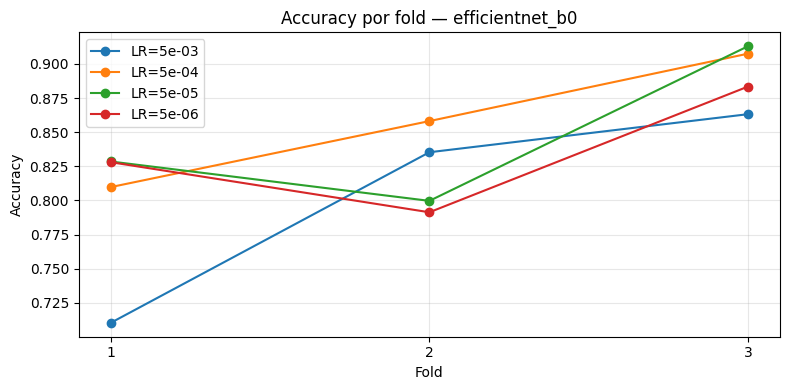

✅ Guardado en results_efficientnet_b0.csv


In [22]:
MODEL_NAME = 'efficientnet_b0'
results_efficientnet = pd.DataFrame()

gkf = GroupKFold(n_splits=CONFIG["n_splits"])
splits = list(gkf.split(np.zeros(len(dataset)),
                         np.array(dataset.labels),
                         dataset.groups_array))

for lr in CONFIG["learning_rates"]:
    print(f"\n{'─'*50}")
    print(f"  EfficientNet-B0 | LR = {lr:.0e}")
    print(f"{'─'*50}")

    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        fold_num = fold_idx + 1
        val_samples = sorted(set(dataset.groups_array[val_idx]),
                             key=lambda x: int(x[1:]))
        print(f"  Fold {fold_num} | Val muestras: {val_samples}")

        torch.manual_seed(CONFIG["random_seed"])
        np.random.seed(CONFIG["random_seed"])

        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, CONFIG["num_classes"])

        train_loader = DataLoader(Subset(dataset, train_idx),
                                  batch_size=CONFIG["batch_size"], shuffle=True)
        val_loader   = DataLoader(Subset(dataset, val_idx),
                                  batch_size=CONFIG["batch_size"], shuffle=False)

        acc, prec, rec, f1 = train_one_fold(model, train_loader, val_loader,
                                             lr, MODEL_NAME)

        print(f"         → Acc: {acc:.4f} | Prec: {prec:.4f} | "
              f"Rec: {rec:.4f} | F1: {f1:.4f}")

        results_efficientnet = pd.concat([
            results_efficientnet,
            pd.DataFrame([{"Model": MODEL_NAME, "LearningRate": lr,
                           "Fold": fold_num, "Accuracy": acc,
                           "Precision": prec, "Recall": rec, "F1": f1,
                           "Val_samples": str(val_samples)}])
        ], ignore_index=True)

        del model
        torch.cuda.empty_cache()

# Guardar y mostrar resumen
results_efficientnet.to_csv("results_efficientnet_b0.csv", index=False)
print_summary(results_efficientnet, MODEL_NAME)
print("✅ Guardado en results_efficientnet_b0.csv")

---
## CELDA 3 — AlexNet


──────────────────────────────────────────────────
  AlexNet | LR = 5e-03
──────────────────────────────────────────────────
  Fold 1 | Val muestras: ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']


         → Acc: 0.4475 | Prec: 0.2002 | Rec: 0.4475 | F1: 0.2767
  Fold 2 | Val muestras: ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']


         → Acc: 0.4919 | Prec: 0.2420 | Rec: 0.4919 | F1: 0.3244
  Fold 3 | Val muestras: ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']


         → Acc: 0.7499 | Prec: 0.5623 | Rec: 0.7499 | F1: 0.6427

──────────────────────────────────────────────────
  AlexNet | LR = 5e-04
──────────────────────────────────────────────────
  Fold 1 | Val muestras: ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']


         → Acc: 0.8442 | Prec: 0.8886 | Rec: 0.8442 | F1: 0.8111
  Fold 2 | Val muestras: ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']


...

         → Acc: 0.8798 | Prec: 0.9075 | Rec: 0.8798 | F1: 0.8808
  Fold 3 | Val muestras: ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']


         → Acc: 0.7340 | Prec: 0.8289 | Rec: 0.7340 | F1: 0.7601

──────────────────────────────────────────────────
  AlexNet | LR = 5e-06
──────────────────────────────────────────────────
  Fold 1 | Val muestras: ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']


         → Acc: 0.8696 | Prec: 0.9049 | Rec: 0.8696 | F1: 0.8498
  Fold 2 | Val muestras: ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']


         → Acc: 0.8147 | Prec: 0.8640 | Rec: 0.8147 | F1: 0.8002
  Fold 3 | Val muestras: ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']


         → Acc: 0.7422 | Prec: 0.8224 | Rec: 0.7422 | F1: 0.7598

  RESUMEN: ALEXNET
             Accuracy              F1        
                 mean     std    mean     std
LearningRate                                 
0.000005       0.8088  0.0639  0.8033  0.0451
0.000050       0.8117  0.0734  0.8043  0.0665
0.000500       0.7996  0.0496  0.7878  0.0739
0.005000       0.5631  0.1633  0.4146  0.1990

  ★ Mejor LR: 5e-05  |  Acc: 0.8117  |  F1: 0.8043



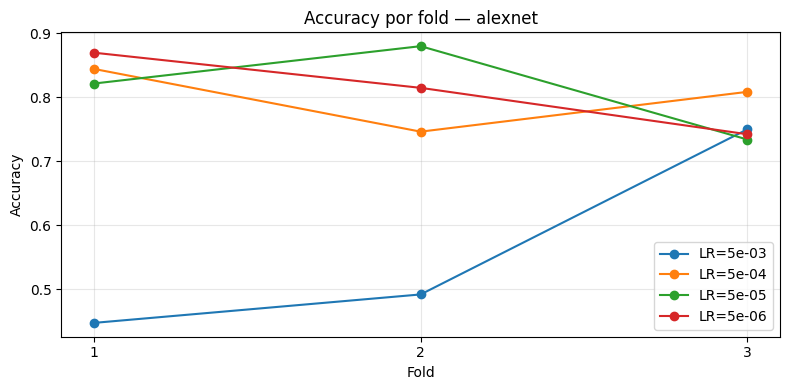

✅ Guardado en results_alexnet.csv


In [23]:
MODEL_NAME = 'alexnet'
results_alexnet = pd.DataFrame()

gkf = GroupKFold(n_splits=CONFIG["n_splits"])
splits = list(gkf.split(np.zeros(len(dataset)),
                         np.array(dataset.labels),
                         dataset.groups_array))

for lr in CONFIG["learning_rates"]:
    print(f"\n{'─'*50}")
    print(f"  AlexNet | LR = {lr:.0e}")
    print(f"{'─'*50}")

    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        fold_num = fold_idx + 1
        val_samples = sorted(set(dataset.groups_array[val_idx]),
                             key=lambda x: int(x[1:]))
        print(f"  Fold {fold_num} | Val muestras: {val_samples}")

        torch.manual_seed(CONFIG["random_seed"])
        np.random.seed(CONFIG["random_seed"])

        model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, CONFIG["num_classes"])

        train_loader = DataLoader(Subset(dataset, train_idx),
                                  batch_size=CONFIG["batch_size"], shuffle=True)
        val_loader   = DataLoader(Subset(dataset, val_idx),
                                  batch_size=CONFIG["batch_size"], shuffle=False)

        acc, prec, rec, f1 = train_one_fold(model, train_loader, val_loader,
                                             lr, MODEL_NAME)

        print(f"         → Acc: {acc:.4f} | Prec: {prec:.4f} | "
              f"Rec: {rec:.4f} | F1: {f1:.4f}")

        results_alexnet = pd.concat([
            results_alexnet,
            pd.DataFrame([{"Model": MODEL_NAME, "LearningRate": lr,
                           "Fold": fold_num, "Accuracy": acc,
                           "Precision": prec, "Recall": rec, "F1": f1,
                           "Val_samples": str(val_samples)}])
        ], ignore_index=True)

        del model
        torch.cuda.empty_cache()

results_alexnet.to_csv("results_alexnet.csv", index=False)
print_summary(results_alexnet, MODEL_NAME)
print("✅ Guardado en results_alexnet.csv")

---
## CELDA 4 — MobileNetV2


──────────────────────────────────────────────────
  MobileNetV2 | LR = 5e-03
──────────────────────────────────────────────────
  Fold 1 | Val muestras: ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']


         → Acc: 0.6560 | Prec: 0.7550 | Rec: 0.6560 | F1: 0.6223
  Fold 2 | Val muestras: ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']


         → Acc: 0.8781 | Prec: 0.9053 | Rec: 0.8781 | F1: 0.8789
  Fold 3 | Val muestras: ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']


         → Acc: 0.8829 | Prec: 0.8957 | Rec: 0.8829 | F1: 0.8757

──────────────────────────────────────────────────
  MobileNetV2 | LR = 5e-04
──────────────────────────────────────────────────
  Fold 1 | Val muestras: ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']


         → Acc: 0.7940 | Prec: 0.6646 | Rec: 0.7940 | F1: 0.7146
  Fold 2 | Val muestras: ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']


...

         → Acc: 0.8264 | Prec: 0.8781 | Rec: 0.8264 | F1: 0.8263
  Fold 3 | Val muestras: ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']


         → Acc: 0.8336 | Prec: 0.8337 | Rec: 0.8336 | F1: 0.8236

──────────────────────────────────────────────────
  MobileNetV2 | LR = 5e-06
──────────────────────────────────────────────────
  Fold 1 | Val muestras: ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']


         → Acc: 0.8234 | Prec: 0.8822 | Rec: 0.8234 | F1: 0.7757
  Fold 2 | Val muestras: ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']


         → Acc: 0.8392 | Prec: 0.8846 | Rec: 0.8392 | F1: 0.8412
  Fold 3 | Val muestras: ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']


         → Acc: 0.8550 | Prec: 0.8788 | Rec: 0.8550 | F1: 0.8428

  RESUMEN: MOBILENETV2
             Accuracy              F1        
                 mean     std    mean     std
LearningRate                                 
0.000005       0.8392  0.0158  0.8199  0.0383
0.000050       0.8180  0.0211  0.8037  0.0368
0.000500       0.8123  0.0356  0.7818  0.0674
0.005000       0.8057  0.1296  0.7923  0.1472

  ★ Mejor LR: 5e-06  |  Acc: 0.8392  |  F1: 0.8199



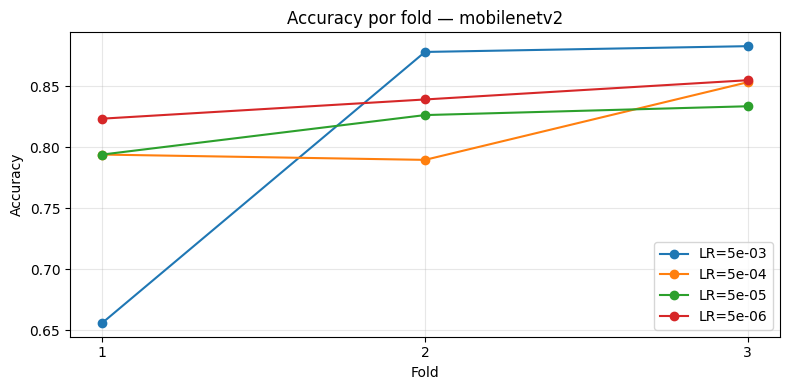

✅ Guardado en results_mobilenetv2.csv


In [24]:
MODEL_NAME = 'mobilenetv2'
results_mobilenet = pd.DataFrame()

gkf = GroupKFold(n_splits=CONFIG["n_splits"])
splits = list(gkf.split(np.zeros(len(dataset)),
                         np.array(dataset.labels),
                         dataset.groups_array))

for lr in CONFIG["learning_rates"]:
    print(f"\n{'─'*50}")
    print(f"  MobileNetV2 | LR = {lr:.0e}")
    print(f"{'─'*50}")

    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        fold_num = fold_idx + 1
        val_samples = sorted(set(dataset.groups_array[val_idx]),
                             key=lambda x: int(x[1:]))
        print(f"  Fold {fold_num} | Val muestras: {val_samples}")

        torch.manual_seed(CONFIG["random_seed"])
        np.random.seed(CONFIG["random_seed"])

        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, CONFIG["num_classes"])

        train_loader = DataLoader(Subset(dataset, train_idx),
                                  batch_size=CONFIG["batch_size"], shuffle=True)
        val_loader   = DataLoader(Subset(dataset, val_idx),
                                  batch_size=CONFIG["batch_size"], shuffle=False)

        acc, prec, rec, f1 = train_one_fold(model, train_loader, val_loader,
                                             lr, MODEL_NAME)

        print(f"         → Acc: {acc:.4f} | Prec: {prec:.4f} | "
              f"Rec: {rec:.4f} | F1: {f1:.4f}")

        results_mobilenet = pd.concat([
            results_mobilenet,
            pd.DataFrame([{"Model": MODEL_NAME, "LearningRate": lr,
                           "Fold": fold_num, "Accuracy": acc,
                           "Precision": prec, "Recall": rec, "F1": f1,
                           "Val_samples": str(val_samples)}])
        ], ignore_index=True)

        del model
        torch.cuda.empty_cache()

results_mobilenet.to_csv("results_mobilenetv2.csv", index=False)
print_summary(results_mobilenet, MODEL_NAME)
print("✅ Guardado en results_mobilenetv2.csv")

---
## CELDA 5 — SqueezeNet 1.0


──────────────────────────────────────────────────
  SqueezeNet 1.0 | LR = 5e-03
──────────────────────────────────────────────────
  Fold 1 | Val muestras: ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']


         → Acc: 0.2055 | Prec: 0.0422 | Rec: 0.2055 | F1: 0.0700
  Fold 2 | Val muestras: ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']


         → Acc: 0.1269 | Prec: 0.0161 | Rec: 0.1269 | F1: 0.0286
  Fold 3 | Val muestras: ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']


         → Acc: 0.0000 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000

──────────────────────────────────────────────────
  SqueezeNet 1.0 | LR = 5e-04
──────────────────────────────────────────────────
  Fold 1 | Val muestras: ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']


         → Acc: 0.8072 | Prec: 0.8761 | Rec: 0.8072 | F1: 0.7430
  Fold 2 | Val muestras: ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']


...

         → Acc: 0.8091 | Prec: 0.8642 | Rec: 0.8091 | F1: 0.8070
  Fold 3 | Val muestras: ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']


         → Acc: 0.8101 | Prec: 0.8745 | Rec: 0.8101 | F1: 0.8240

──────────────────────────────────────────────────
  SqueezeNet 1.0 | LR = 5e-06
──────────────────────────────────────────────────
  Fold 1 | Val muestras: ['S1', 'S3', 'S5', 'S9', 'S13', 'S22', 'S26', 'S27', 'S30']


         → Acc: 0.8691 | Prec: 0.9043 | Rec: 0.8691 | F1: 0.8493
  Fold 2 | Val muestras: ['S4', 'S7', 'S10', 'S11', 'S17', 'S19', 'S23', 'S24']


         → Acc: 0.8759 | Prec: 0.8837 | Rec: 0.8759 | F1: 0.8452
  Fold 3 | Val muestras: ['S6', 'S14', 'S15', 'S16', 'S20', 'S21', 'S28', 'S29']


         → Acc: 0.7685 | Prec: 0.8207 | Rec: 0.7685 | F1: 0.7817

  RESUMEN: SQUEEZENET
             Accuracy              F1        
                 mean     std    mean     std
LearningRate                                 
0.000005       0.8378  0.0602  0.8254  0.0379
0.000050       0.8362  0.0461  0.8360  0.0366
0.000500       0.8145  0.0634  0.7936  0.0955
0.005000       0.1108  0.1037  0.0329  0.0352

  ★ Mejor LR: 5e-06  |  Acc: 0.8378  |  F1: 0.8360



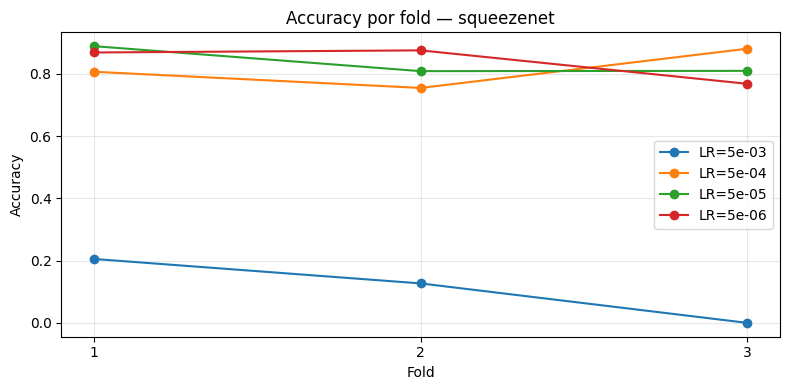

✅ Guardado en results_squeezenet.csv


In [25]:
MODEL_NAME = 'squeezenet'
results_squeezenet = pd.DataFrame()

gkf = GroupKFold(n_splits=CONFIG["n_splits"])
splits = list(gkf.split(np.zeros(len(dataset)),
                         np.array(dataset.labels),
                         dataset.groups_array))

for lr in CONFIG["learning_rates"]:
    print(f"\n{'─'*50}")
    print(f"  SqueezeNet 1.0 | LR = {lr:.0e}")
    print(f"{'─'*50}")

    for fold_idx, (train_idx, val_idx) in enumerate(splits):
        fold_num = fold_idx + 1
        val_samples = sorted(set(dataset.groups_array[val_idx]),
                             key=lambda x: int(x[1:]))
        print(f"  Fold {fold_num} | Val muestras: {val_samples}")

        torch.manual_seed(CONFIG["random_seed"])
        np.random.seed(CONFIG["random_seed"])

        model = models.squeezenet1_0(weights=models.SqueezeNet1_0_Weights.DEFAULT)
        model.classifier[1] = nn.Conv2d(512, CONFIG["num_classes"], kernel_size=(1, 1))
        model.num_classes = CONFIG["num_classes"]

        train_loader = DataLoader(Subset(dataset, train_idx),
                                  batch_size=CONFIG["batch_size"], shuffle=True)
        val_loader   = DataLoader(Subset(dataset, val_idx),
                                  batch_size=CONFIG["batch_size"], shuffle=False)

        acc, prec, rec, f1 = train_one_fold(model, train_loader, val_loader,
                                             lr, MODEL_NAME)

        print(f"         → Acc: {acc:.4f} | Prec: {prec:.4f} | "
              f"Rec: {rec:.4f} | F1: {f1:.4f}")

        results_squeezenet = pd.concat([
            results_squeezenet,
            pd.DataFrame([{"Model": MODEL_NAME, "LearningRate": lr,
                           "Fold": fold_num, "Accuracy": acc,
                           "Precision": prec, "Recall": rec, "F1": f1,
                           "Val_samples": str(val_samples)}])
        ], ignore_index=True)

        del model
        torch.cuda.empty_cache()

results_squeezenet.to_csv("results_squeezenet.csv", index=False)
print_summary(results_squeezenet, MODEL_NAME)
print("✅ Guardado en results_squeezenet.csv")

---
## CELDA 6 — Resumen comparativo final (corre al tener todos los modelos)

In [26]:
# Combina todos los resultados
all_results = pd.concat([
    results_efficientnet,
    results_alexnet,
    results_mobilenet,
    results_squeezenet
], ignore_index=True)

all_results.to_csv("gridsearch_groupkfold_ALL.csv", index=False)

print("\n" + "="*65)
print("  RESUMEN FINAL — MEJOR LR POR MODELO")
print("="*65)
print(f"  {'Modelo':<22} | {'Mejor LR':>9} | {'Acc mean':>9} | {'Acc std':>8} | {'F1 mean':>8}")
print("-"*65)

for model_name in ['efficientnet_b0', 'alexnet', 'mobilenetv2', 'squeezenet']:
    subset = all_results[all_results['Model'] == model_name]
    summary = subset.groupby('LearningRate')[['Accuracy', 'F1']].mean()
    best_lr  = summary['Accuracy'].idxmax()
    best_acc = summary.loc[best_lr, 'Accuracy']
    best_std = subset[subset['LearningRate'] == best_lr]['Accuracy'].std()
    best_f1  = summary.loc[best_lr, 'F1']
    print(f"  {model_name:<22} | {best_lr:>9.0e} | {best_acc:>9.4f} | "
          f"{best_std:>8.4f} | {best_f1:>8.4f}")

print("="*65)
print("\n✅ Guardado en gridsearch_groupkfold_ALL.csv")


  RESUMEN FINAL — MEJOR LR POR MODELO
  Modelo                 |  Mejor LR |  Acc mean |  Acc std |  F1 mean
-----------------------------------------------------------------
  efficientnet_b0        |     5e-04 |    0.8584 |   0.0489 |   0.8392
  alexnet                |     5e-05 |    0.8117 |   0.0734 |   0.8043
  mobilenetv2            |     5e-06 |    0.8392 |   0.0158 |   0.8199
  squeezenet             |     5e-06 |    0.8378 |   0.0602 |   0.8254

✅ Guardado en gridsearch_groupkfold_ALL.csv
